In [1]:
import pandas as pd
import numpy as np
import pickle as pkl
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/compas-scores-two-years.csv")
# repeat preprocessing from ProPublica
df = df[(df["days_b_screening_arrest"] <= 30)
        & (df["days_b_screening_arrest"] >= -30)
        & (df["is_recid"] != -1)
        & (df["c_charge_degree"] != 'O')
        & (df["score_text"] != 'N/A')].reset_index(drop=True)
df = df[df.race.isin(['African-American', 'Caucasian'])]

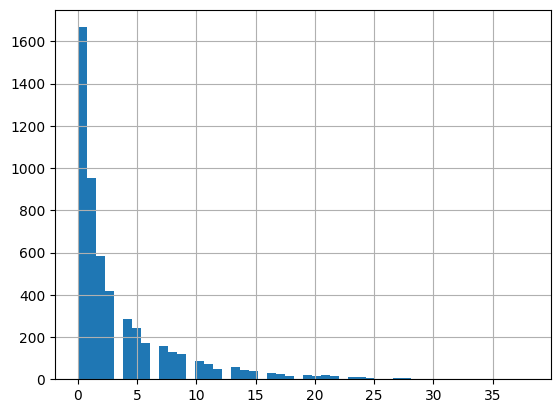

In [5]:
df["priors_count"].hist(bins = 50);

In [6]:
def age_cat(age):
    if age < 25:
        return 0
    elif age < 35:
        return 1
    elif age < 45:
        return 2
    elif age < 55:
        return 3
    else:
        return 4

def priors_count_cat(count):
    if count <= 5:
        return count
    elif count <= 10:
        return 6
    else:
        return 7

df['age_cat'] = df['age'].apply(age_cat)
df['priors_count_cat'] = df['priors_count'].apply(priors_count_cat)

In [7]:
# create model and pool

# calculate frequency of two_year_recid for each group
grouped = df.groupby(["race", "age_cat", "priors_count_cat"])
freq = grouped["two_year_recid"].mean().reset_index()

# transform freq into a dictionary for easy access
freq_dict = {}
for i, row in freq.iterrows():
    race = 1 if row['race'] == 'Caucasian' else 0
    key = (race, row["age_cat"], row["priors_count_cat"])
    freq_dict[key] = row["two_year_recid"]


pool = []
for i, row in df.iterrows():
    group = 1 if row["race"] == "Caucasian" else 0
    # features are one-hot-encoded age_cat and priors_count_cat
    features = []
    for age_cat in sorted(df["age_cat"].unique()):
        features.append(1 if row["age_cat"] == age_cat else 0)
    for priors_count_cat in sorted(df["priors_count_cat"].unique()):
        features.append(1 if row["priors_count_cat"] == priors_count_cat else 0)
    pool.append(
        {
            "features": np.array(features),
            "group": group,
        }
    )

with open("data/compas_pool.pkl", "wb") as f:
    pkl.dump(pool, f)

with open("data/compas_model.pkl", "wb") as f:
    pkl.dump(freq_dict, f)

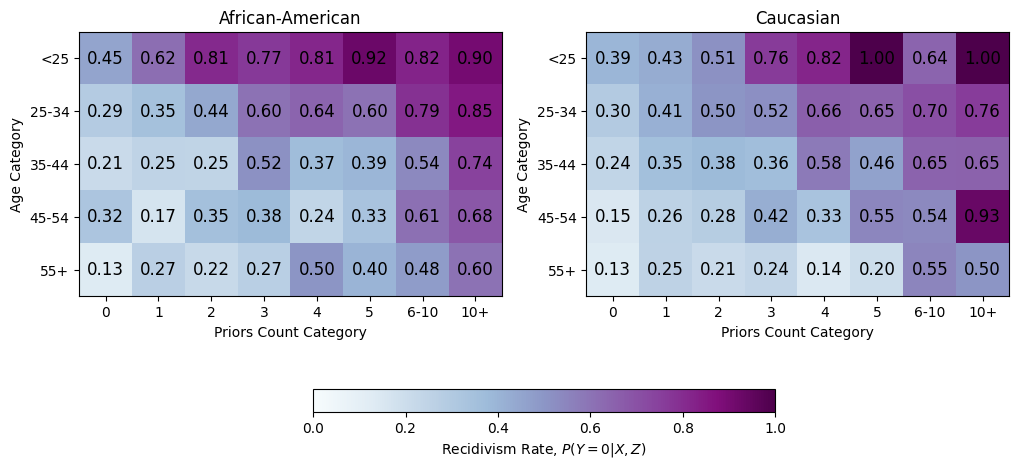

In [15]:
# create two heatmaps of [age_cat, priors_count_cat] vs recidivism rate

n_age_cat = len(df["age_cat"].unique())
n_priors_count_cat = len(df["priors_count_cat"].unique())

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

for i in range(2):

    heatmap_data = np.zeros((n_age_cat, n_priors_count_cat))
    for age_cat in range(n_age_cat):
        for priors_count_cat in range(n_priors_count_cat):
            key = (i, age_cat, priors_count_cat)
            heatmap_data[age_cat, priors_count_cat] = freq_dict.get(key, 0)

    axs[i].imshow(heatmap_data, cmap="BuPu", vmin=0, vmax=1)

    axs[i].set_title("Caucasian" if i == 1 else "African-American")
    axs[i].set_xlabel("Priors Count Category")
    axs[i].set_ylabel("Age Category")
    axs[i].set_xticks(np.arange(n_priors_count_cat))
    axs[i].set_yticks(np.arange(n_age_cat))
    axs[i].set_xticklabels([0, 1, 2, 3, 4, 5, '6-10', '10+'])
    axs[i].set_yticklabels(['<25', '25-34', '35-44', '45-54', '55+'])

    # annotate each cell with the recidivism rate
    for age_cat in range(n_age_cat):
        for priors_count_cat in range(n_priors_count_cat):
            rate = heatmap_data[age_cat, priors_count_cat]
            axs[i].text(priors_count_cat, age_cat, f"{rate:.2f}",
                        ha="center", va="center", color="black", fontsize=12)



# add a colorbar with small height
cbar = fig.colorbar(axs[1].images[0], ax=axs, orientation='horizontal', fraction=0.05, pad=0.2)
cbar.set_label('Recidivism Rate, $P(Y = 0 | X, Z)$')

plt.savefig("figures/compas.pdf")
plt.show()